
Project Title: Deep Learning for Automated Cell Counting in Microscopy Images

Team Member:
Amy Seo (jungmin.seo.manchester@gmail.com)
Dingshan Deng (dingshandeng@gmail.com)
Pranjal Singh (singhp19@msu.edu)
Ruiping Huang (rhuang26@uic.edu)


Dataset: https://universe.roboflow.com/cell-counting/cell-counting-zeqo5/browse?queryText=&pageSize=100&startingIndex=0&browseQuery=true$0


# 1. Exploratory Data Analysis (EDA)

### Installing libraries

In [1]:
!pip install roboflow

In [2]:
from google.colab import userdata
from roboflow import Roboflow
import os
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

### Getting the dataset

In [3]:
api_key = userdata.get("ROBOFLOW_API_KEY") #key acquired from roboflow universe

In [4]:
rf = Roboflow(api_key=api_key)
project = rf.workspace("pranjal-singh-evqc5").project(
    "cell-counting-zeqo5-raras"
)

version = project.version(1) #version generated on roboflow universe
dataset = version.download("coco") #chose this formar for PyTorch compatibality

loading Roboflow workspace...
loading Roboflow project...


In [5]:
print(type(dataset))
print(dataset.name)
dataset_path = dataset.location #need the location to find subfolders
print(dataset.location)
print(dataset.model_format) #double checking if format is correct

print(os.listdir(dataset_path)) #all subfolders & files in dataset

for folder in ['train', 'valid', 'test']:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.exists(folder_path):
        print(f"Total files {folder}: {len(os.listdir(folder_path))}")

<class 'roboflow.core.dataset.Dataset'>
cell counting
/content/cell-counting-1
coco
['valid', 'test', 'README.roboflow.txt', 'train']
Total files train: 351
Total files valid: 101
Total files test: 51


#### Inspeacting README

In [6]:
# with open(os.path.join(dataset_path,"README.roboflow.txt"),"r") as f: #inspecting read me
#   readme_text = f.read()

# print(readme_text)


### Inspecting file types

In [7]:
data_dir = Path(dataset_path + "/train") #path to train dir
file_types = {file.suffix.lower() for file in data_dir.rglob("*") if file.is_file() and file.suffix} #all file types  (from ai)

print(f"File types found in directory: {[ext for ext in file_types]}") #.jpg files are images and .json is labels

json_file = [file.name for file in data_dir.glob("*.json") if file.is_file()]
print(f"Json file (w/labels) name: {json_file[0]}") #json file wiht training labels

with open(data_dir/Path(json_file[0]),"r") as file:
  data = json.load(file)

# print(json.dumps(data, indent=4))

ann_df = pd.DataFrame(data["annotations"])
img_df = pd.DataFrame(data["images"])
cat_df = pd.DataFrame(data["categories"])
img_df.head()



File types found in directory: ['.json', '.jpg']
Json file (w/labels) name: _annotations.coco.json


,id,license,file_name,height,width,date_captured,extra
0,0,1,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,2026-10-06T16:32:03+00:00,{'name': '2022_12_7_1_B-creport_275.jpg'}
1,1,1,2022_12_7_1_B-creport_267_jpg.rf.e2f9c2899dd93...,640,640,2026-10-06T16:32:03+00:00,{'name': '2022_12_7_1_B-creport_267.jpg'}
2,2,1,2022_12_7_2_B-creport_526_jpg.rf.4e10939bc6e3b...,640,640,2026-10-06T16:32:03+00:00,{'name': '2022_12_7_2_B-creport_526.jpg'}
3,3,1,2022_12_7_1_B-creport_272_jpg.rf.804d9e0436218...,640,640,2026-10-06T16:32:03+00:00,{'name': '2022_12_7_1_B-creport_272.jpg'}
4,4,1,2022_12_7_1_B-creport_271_jpg.rf.21a473e49f08f...,640,640,2026-10-06T16:32:03+00:00,{'name': '2022_12_7_1_B-creport_271.jpg'}


In [8]:
cat_df.head()

,id,name,supercategory
0,0,cell,none
1,1,Dead,cell
2,2,Live,cell


In [9]:
ann_df.head()

,id,image_id,category_id,bbox,iscrowd,area,segmentation
0,1,0,2,"[301, 17, 30, 30]",0,900.00,[]
1,2,0,2,"[329, 45, 25.5, 25.5]",0,650.25,[]
2,3,0,2,"[150, 15, 30, 27.5]",0,825.00,[]
3,4,0,2,"[111, 39, 34, 27.5]",0,935.00,[]
4,5,0,2,"[81, 60, 25.5, 23.5]",0,599.25,[]


In [10]:
ann_df[["x", "y", "w", "h"]] = pd.DataFrame(ann_df["bbox"].tolist(), index=ann_df.index)
ann_df = ann_df.drop(columns=["bbox", "segmentation"])

df = (
    ann_df
    .merge(img_df[["id", "file_name", "width", "height"]]
           .rename(columns={"id": "image_id", "width": "img_w", "height": "img_h"}),
           on="image_id")
    .merge(cat_df[["id", "name"]]
           .rename(columns={"id": "category_id", "name": "category"}),
           on="category_id")
)
df.head()

,id,image_id,category_id,iscrowd,area,x,y,w,h,file_name,img_w,img_h,category
0,1,0,2,0,900.00,301,17,30.0,30.0,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,Live
1,2,0,2,0,650.25,329,45,25.5,25.5,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,Live
2,3,0,2,0,825.00,150,15,30.0,27.5,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,Live
3,4,0,2,0,935.00,111,39,34.0,27.5,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,Live
4,5,0,2,0,599.25,81,60,25.5,23.5,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,Live


In [11]:
cells_per_image = ann_df.groupby("image_id").size().rename("n_cells") #need to group all cells in a single image
cells_per_image.head()

,n_cells
image_id,
0,60
1,82
2,42
3,83
4,82


In [26]:
counts = (
    img_df[["id", "file_name","height","width"]].rename(columns={"id": "image_id"})
    .merge(cells_per_image, on="image_id", how="left")
    .fillna({"n_cells": 0})
    .astype({"n_cells": int})
) #creating a new dataset with id, # of cells and file name

counts.head()

,image_id,file_name,height,width,n_cells
0,0,2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21ea...,640,640,60
1,1,2022_12_7_1_B-creport_267_jpg.rf.e2f9c2899dd93...,640,640,82
2,2,2022_12_7_2_B-creport_526_jpg.rf.4e10939bc6e3b...,640,640,42
3,3,2022_12_7_1_B-creport_272_jpg.rf.804d9e0436218...,640,640,83
4,4,2022_12_7_1_B-creport_271_jpg.rf.21a473e49f08f...,640,640,82


### Examples of what the data looks like

In [13]:
file_names = [data_dir/Path(file) for file in counts.head()["file_name"]]

print(file_names)

[PosixPath('/content/cell-counting-1/train/2022_12_7_1_B-creport_275_jpg.rf.545fabe9f21eac100f408e2076d6a7fc.jpg'), PosixPath('/content/cell-counting-1/train/2022_12_7_1_B-creport_267_jpg.rf.e2f9c2899dd93a02082ee9b75a964718.jpg'), PosixPath('/content/cell-counting-1/train/2022_12_7_2_B-creport_526_jpg.rf.4e10939bc6e3b74c09328aa161e5f3f7.jpg'), PosixPath('/content/cell-counting-1/train/2022_12_7_1_B-creport_272_jpg.rf.804d9e04362186c565c3a08da3d4d9b4.jpg'), PosixPath('/content/cell-counting-1/train/2022_12_7_1_B-creport_271_jpg.rf.21a473e49f08feebd5217969432543e8.jpg')]


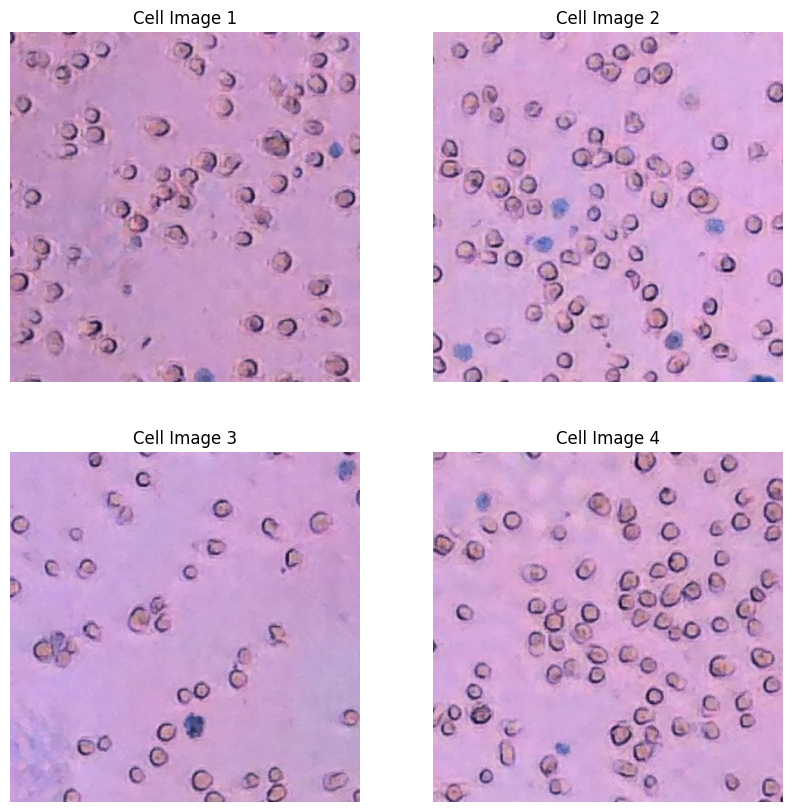

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(file_names[:4]):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide grid lines and pixel ticks
    axes[i].set_title(f"Cell Image {i+1}")  # Optional title

### Labels Distribution (Train Set)

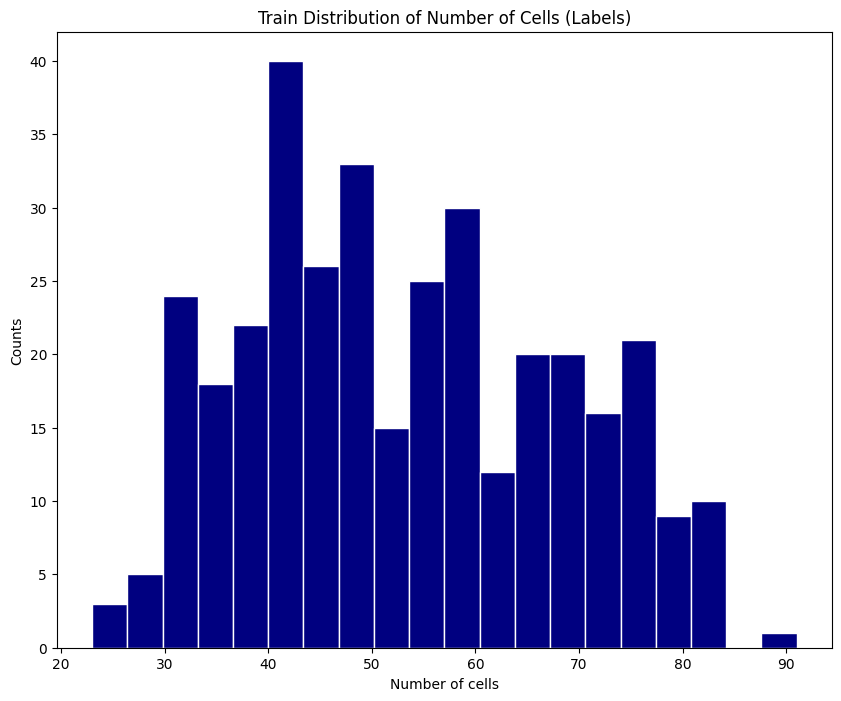

In [27]:
fig, ax =  plt.subplots(figsize=(10, 8))

ax.hist(counts["n_cells"], bins=20, color="navy", edgecolor="white")
ax.set_xlabel("Number of cells")
ax.set_ylabel("Counts")
ax.set_title("Train Distribution of Number of Cells (Labels)")
plt.show()

### Confirming all images are same size

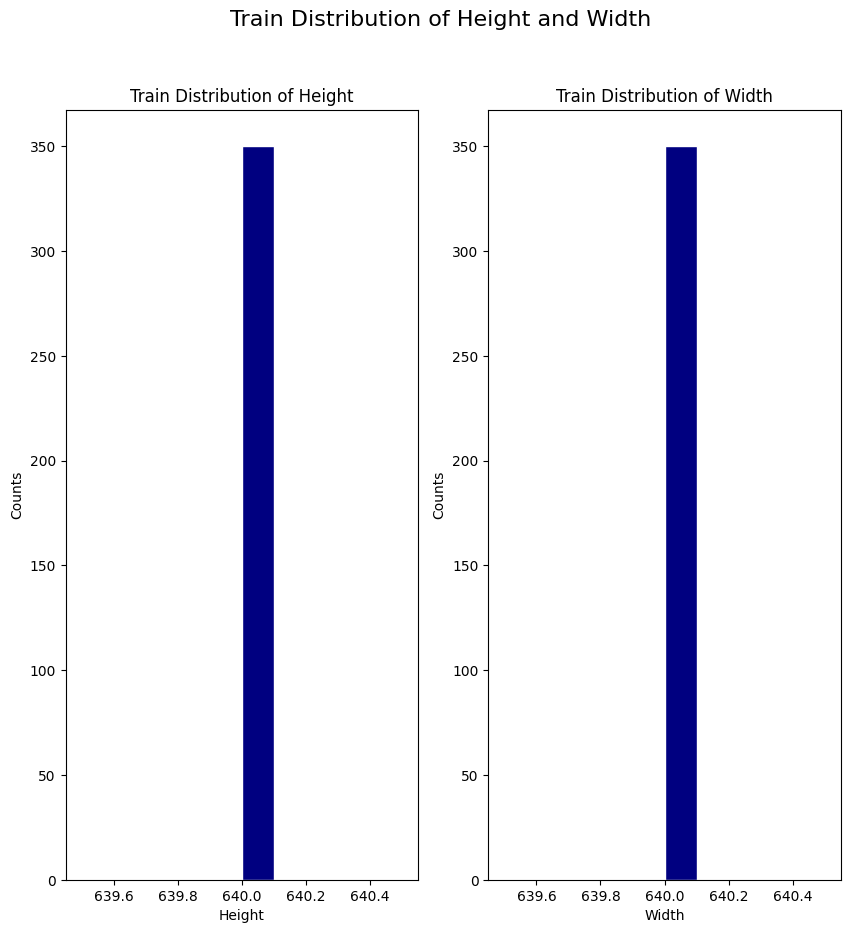

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes = axes.flatten()

axes[0].hist(counts["height"], bins=10, color="navy", edgecolor="white")
axes[0].set_xlabel("Height")
axes[0].set_ylabel("Counts")
axes[0].set_title("Train Distribution of Height")

axes[1].hist(counts["width"], bins=10, color="navy", edgecolor="white")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Counts")
axes[1].set_title("Train Distribution of Width")

plt.suptitle("Train Distribution of Height and Width", fontsize=16)
plt.show()


### Checking for Nans in dataset (any images w/o labels)

In [33]:
counts.isna().sum() #doesn't seem like there are any nans

,0
image_id,0
file_name,0
height,0
width,0
n_cells,0


In [37]:
#since we're not looking into live vs dead cells, their presence could be problematic

dead_id = cat_df.loc[cat_df["name"].str.lower() == "dead", "id"].iloc[0]

dead_per_image = (
    ann_df[ann_df["category_id"] == dead_id]
    .groupby("image_id").size()
    .rename("n_dead")
)

dead_per_image.head()

,n_dead
image_id,
0,2
1,6
2,3
3,2
4,3


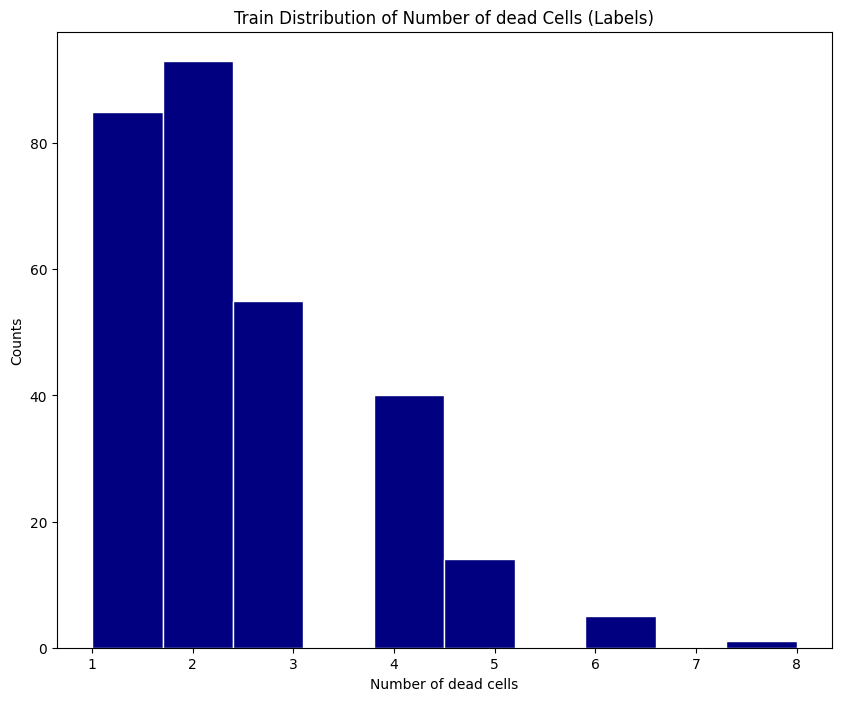

In [40]:
fig, ax =  plt.subplots(figsize=(10, 8))

ax.hist(dead_per_image, bins=10, color="navy", edgecolor="white")
ax.set_xlabel("Number of dead cells")
ax.set_ylabel("Counts")
ax.set_title("Train Distribution of Number of dead Cells (Labels)")
plt.show()